# Random Forest

-   هو مجموعه من اشجار القرار
-   لكل ادخال نرى الاكثر شيوعا بين الاشجار ونقوم بارجاعه كمخرج
-   واذا كان انحدار عن طريق المتوسط جمع جميع الارقام ثم ارجاع المتوسط
-   اختيار عشوائي للميزات (العواميد)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import opendatasets as od
%matplotlib inline

In [3]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', None)

In [4]:
od.download('https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package')

Skipping, found downloaded files in ".\weather-dataset-rattle-package" (use force=True to force download)


In [5]:
os.listdir('./weather-dataset-rattle-package')

['weatherAUS.csv']

In [6]:
rain_df = pd.read_csv('./weather-dataset-rattle-package/weatherAUS.csv')

In [7]:
rain_df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [8]:
rain_df.dropna(subset = 'RainTomorrow', inplace = True)

In [9]:
rain_df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
dtype: int64

In [10]:
year = pd.to_datetime(rain_df.Date).dt.year
train_df = rain_df[year < 2015]
val_df = rain_df[year == 2015]
test_df = rain_df[year > 2015]

In [11]:
inputs_cols = rain_df.columns[1:-1].tolist()
targets_cols = 'RainTomorrow'

In [12]:
train_inputs = train_df[inputs_cols].copy()
train_targets = train_df[targets_cols].copy()

val_inputs = val_df[inputs_cols].copy()
val_targets = val_df[targets_cols].copy()

test_inputs = test_df[inputs_cols].copy()
test_targets = test_df[targets_cols].copy()

In [13]:
numeric_cols = rain_df.select_dtypes(include = 'number').columns.tolist()
categorical_cols = rain_df.select_dtypes(include = 'object').columns[1 : -1].tolist()

In [14]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'mean').fit(train_inputs[numeric_cols])

In [15]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [16]:
train_inputs[numeric_cols].isnull().sum().sort_values(ascending = False)

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

In [17]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler().fit(train_inputs[numeric_cols])

In [18]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [19]:
val_inputs.describe().loc[['min','max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,-2.197802,-2.56,0.0,-2.937144,-4.471845,-2.133333,-1.083333,-1.727273,-2.500000,-1.857143,-3.502148,-3.921253,-1.436016,-1.471484,-2.505495,-2.631579
max,2.208791,2.30,309.0,36.173967,4.057567,6.400000,6.166667,5.000000,1.192308,1.714286,2.593090,2.638271,1.230651,1.195183,2.296703,2.294737


In [20]:
train_inputs[categorical_cols] = train_inputs[categorical_cols] .fillna('Unknown')
val_inputs[categorical_cols] = val_inputs[categorical_cols].fillna('Unknown')
test_inputs[categorical_cols] = test_inputs[categorical_cols].fillna('Unknown')

In [21]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore').fit(train_inputs[categorical_cols])

In [22]:
encoded_cols = list(encoder.get_feature_names_out())

In [23]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

C:\Users\aa\AppData\Local\Temp\ipykernel_16492\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_16492\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_16492\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [24]:
x_train = train_inputs[numeric_cols + encoded_cols]
x_val = val_inputs[numeric_cols + encoded_cols]
x_test = test_inputs[numeric_cols + encoded_cols]

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the 

In [27]:
%%time
model = RandomForestClassifier(n_jobs = -1, random_state = 42)

CPU times: total: 0 ns
Wall time: 0 ns


In [28]:
%%time
model.fit(x_train, train_targets)

CPU times: total: 42.1 s
Wall time: 5.77 s


RandomForestClassifier(n_jobs=-1, random_state=42)

In [29]:
def predict (inputs, targets, name = ' '):
    preds = model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print('Accuracy {:.2f}%'.format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize = 'true')
    plt.figure()
    sns.heatmap(data = cf, annot= True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

Accuracy 100.00%


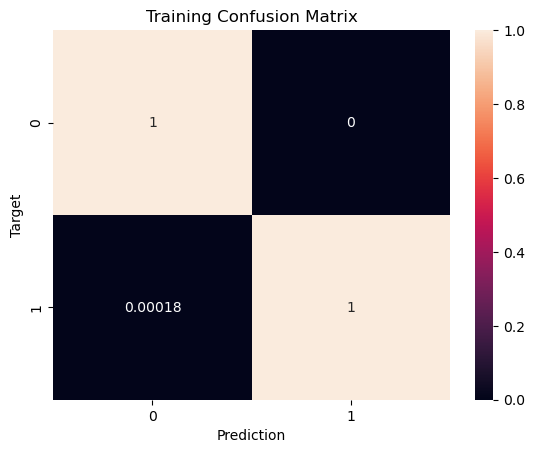

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [30]:
predict(x_train, train_targets, 'Training')

Accuracy 85.68%


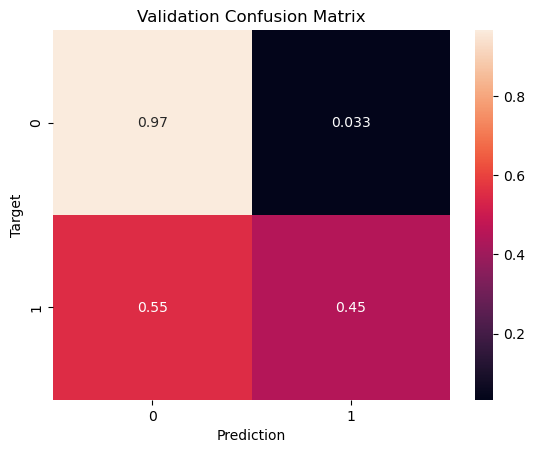

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [31]:
predict(x_val, val_targets, 'Validation')

In [32]:
train_probs = model.predict_proba(x_train)
train_probs

array([[0.93, 0.07],
       [0.96, 0.04],
       [0.98, 0.02],
       ...,
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.96, 0.04]])

In [33]:
#   يمكن من خلال هذه التعليمه ان نرى الاشجار
len(model.estimators_)

100

In [34]:
#   نذهب لاي شجره من المئه
model.estimators_[5]

DecisionTreeClassifier(max_features='sqrt', random_state=1201263687)

In [35]:
from sklearn.tree import export_text, plot_tree

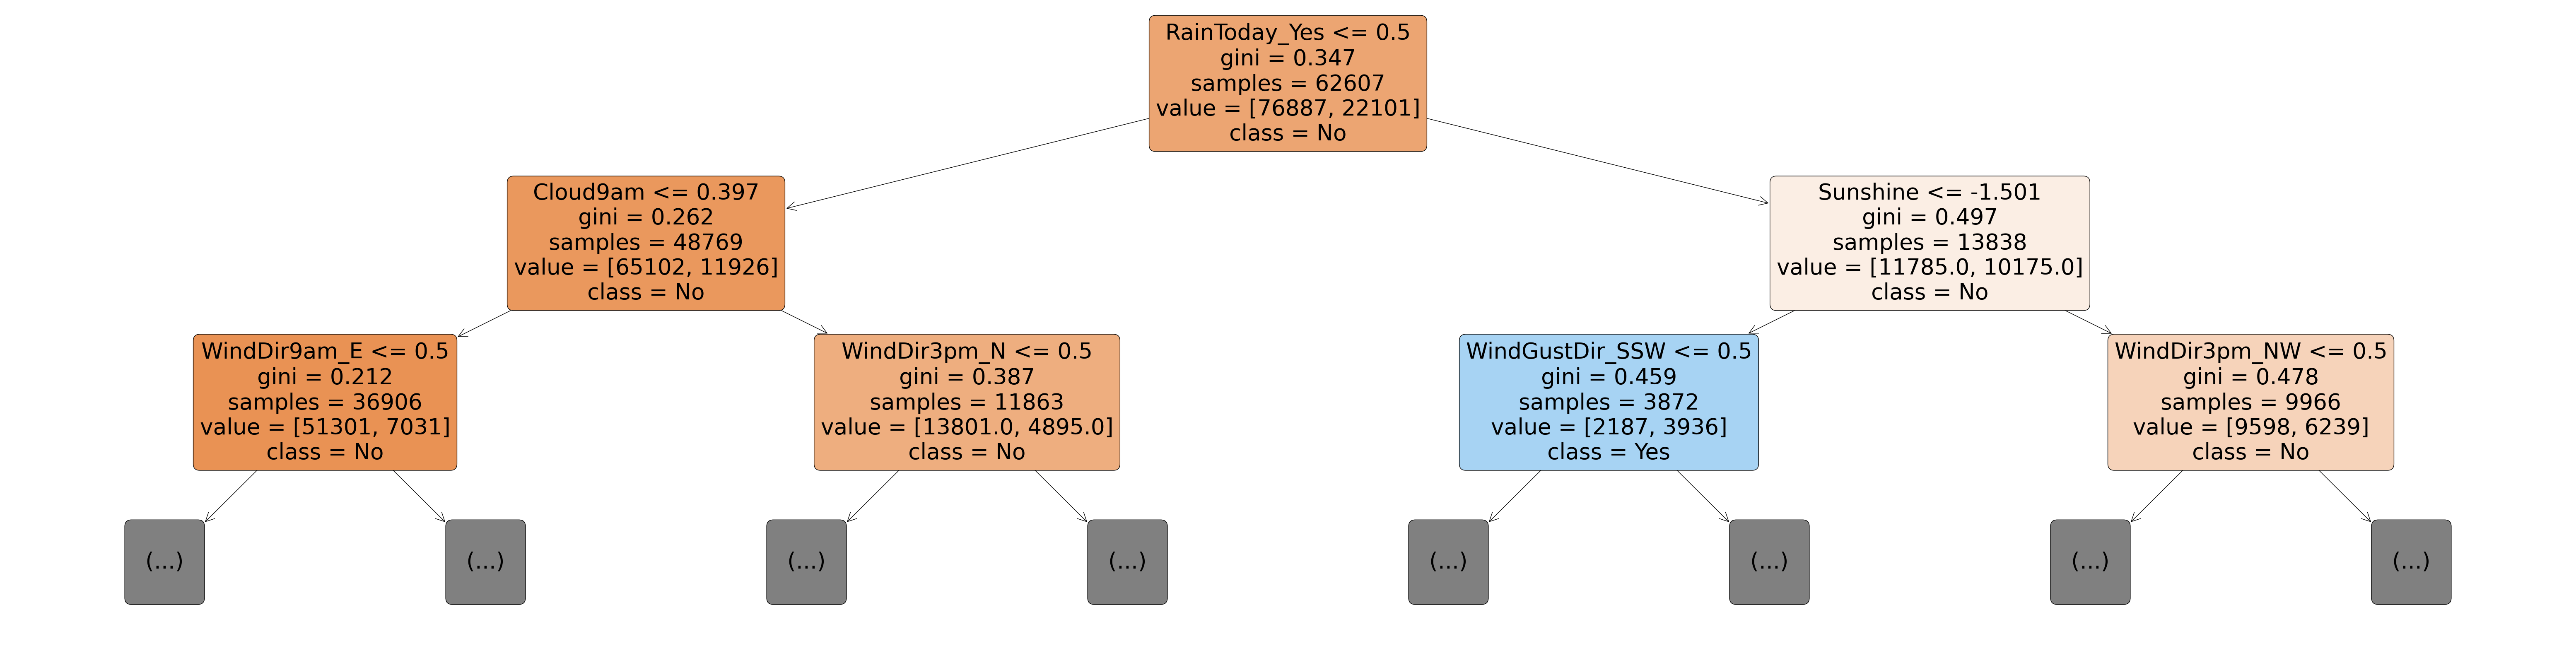

In [36]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[0], max_depth =2, feature_names = x_train.columns, rounded = True, class_names = model.classes_, filled = True)
plt.show()

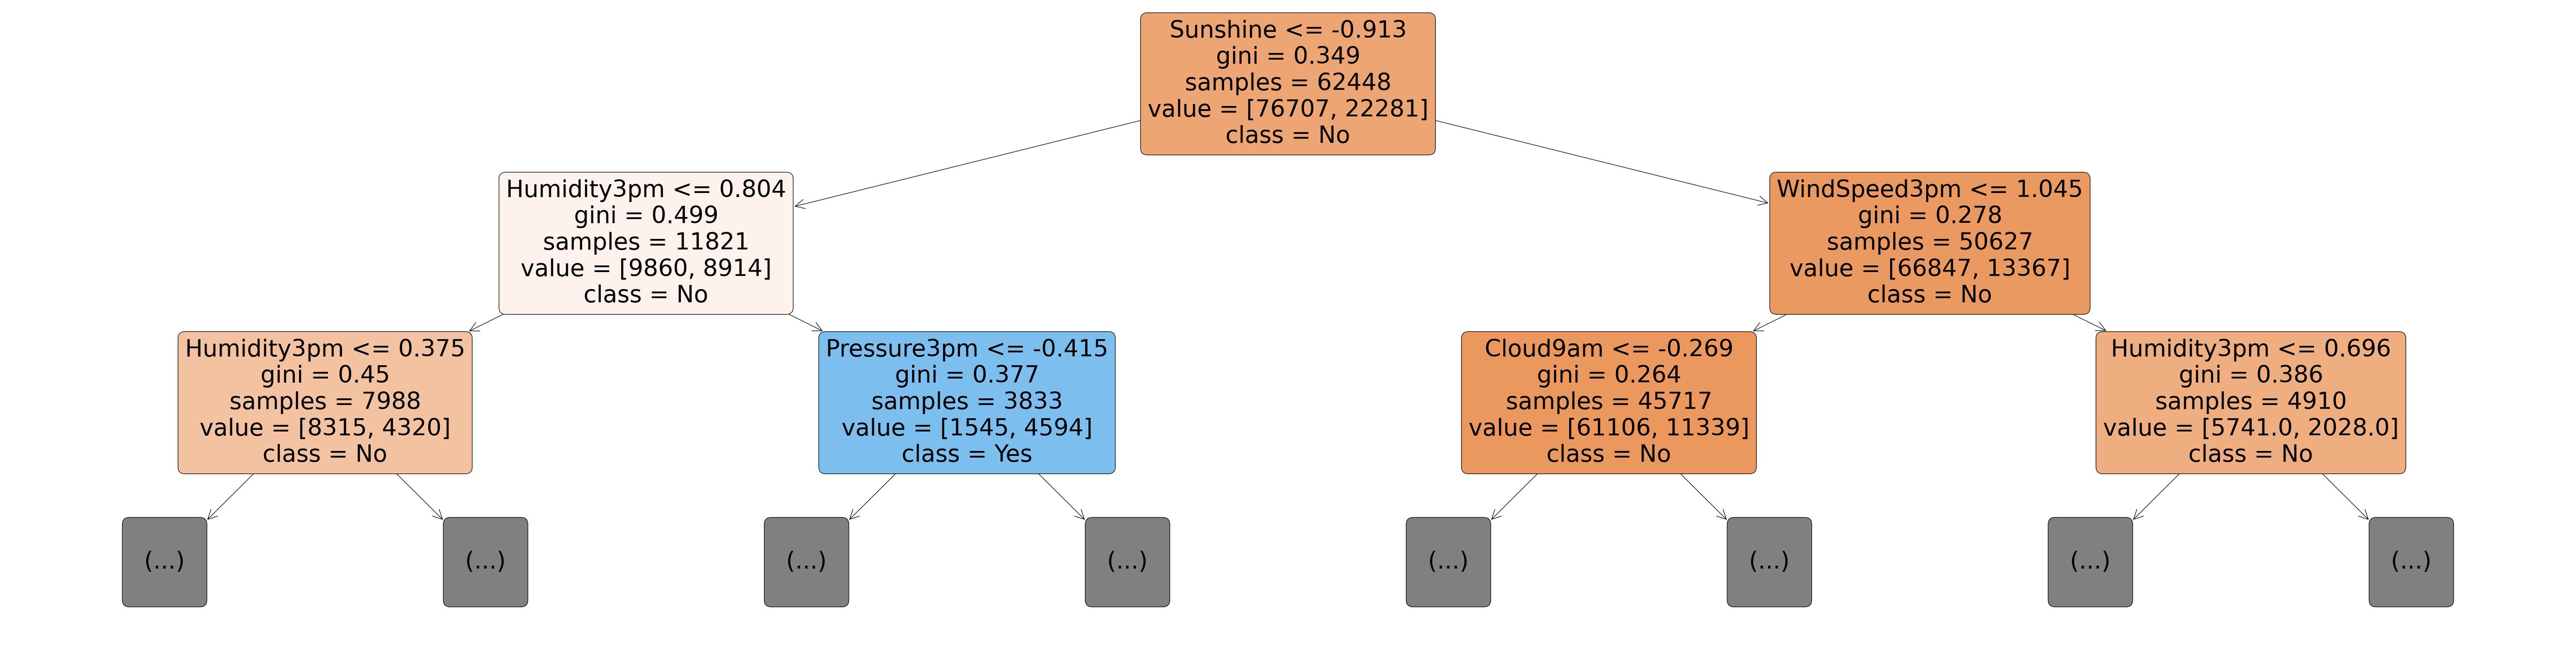

In [37]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[15], max_depth =2, feature_names = x_train.columns, rounded = True, class_names = model.classes_, filled = True)
plt.show()

In [38]:
importance_df = pd.DataFrame({
    'features' : x_train.columns,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending = False)

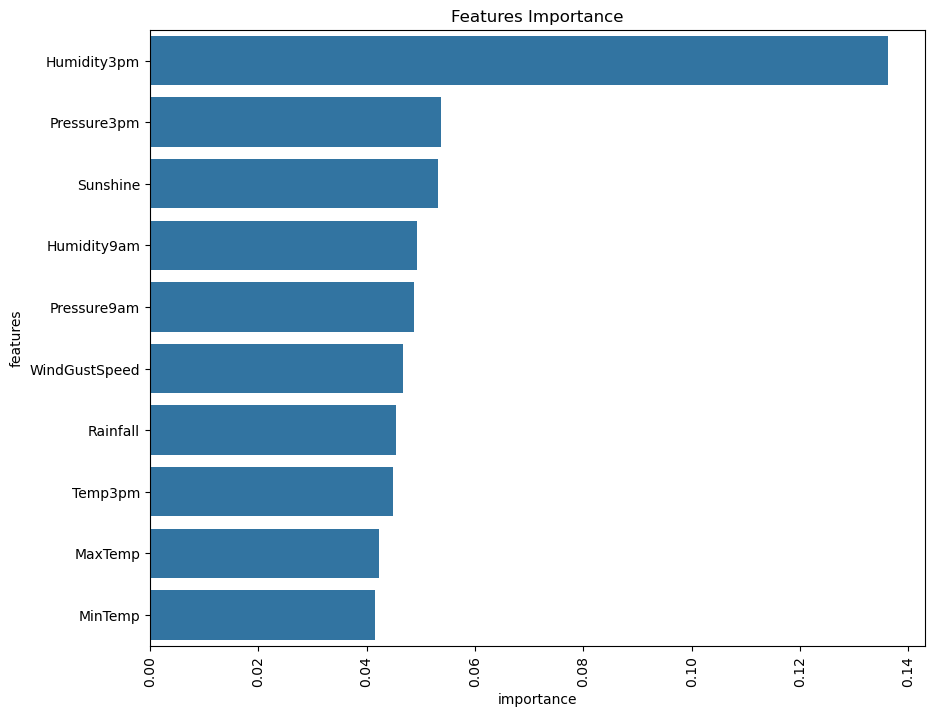

In [39]:
plt.figure(figsize = (10, 8))
plt.title('Features Importance')
sns.barplot(data = importance_df.head(10), y = 'features', x = 'importance')
plt.xticks(rotation = 90)
plt.show()

# Hyperparameter Tuning with Random Forests

In [41]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the 

In [42]:
%%time
base_model = RandomForestClassifier(n_jobs = -1, random_state = 42).fit(x_train, train_targets)

CPU times: total: 41.2 s
Wall time: 5.59 s


In [43]:
base_train_acc = base_model.score(x_train, train_targets)
base_val_acc = base_model.score(x_val, val_targets)

In [44]:
base_acc = base_train_acc, base_val_acc
base_acc

(0.9999595910615429, 0.8567697754047937)

1-  n_estimators

-  عدد الاشجار في الغابه العشوائيه زياده العدد قد يحسن الدقه
-  كلما زادت تزيد العشوائيه والقرار وتقلل الافراط في التعلم
-  اذا كانت واحد قد يحدث افراط في التعلم
-  التجريب بالضعف لمعرفه افضل قيمه 100 و200 و 400 و 800

In [46]:
%%time
model = RandomForestClassifier(n_jobs = -1, random_state = 42, n_estimators = 10).fit(x_train, train_targets)

CPU times: total: 3.97 s
Wall time: 839 ms


In [47]:
model.score(x_train, train_targets),model.score(x_val, val_targets)

(0.9870893441629288, 0.845801172305728)

In [48]:
base_acc

(0.9999595910615429, 0.8567697754047937)

In [49]:
%%time
model = RandomForestClassifier(n_jobs = -1, random_state = 42, n_estimators = 500).fit(x_train, train_targets)

CPU times: total: 3min 47s
Wall time: 29.7 s


In [50]:
model.score(x_train, train_targets),model.score(x_val, val_targets)

(0.9999797955307714, 0.8582786837676281)

In [51]:
base_acc

(0.9999595910615429, 0.8567697754047937)

In [52]:
def max_nTrees_error(md):
    model = RandomForestClassifier(n_jobs = -1, random_state = 42, n_estimators = md)
    model.fit(x_train, train_targets)
    train_acc = 1 - model.score(x_train, train_targets)
    val_acc = 1 - model.score(x_val, val_targets)
    return{'max n trees' : md, 'Training Error' : train_acc, 'Validation Error' : val_acc}
md_values = []
md = 100
while md < 4000 :
    md_values.append(md)
    md *= 2
errors_df = pd.DataFrame([max_nTrees_error(md) for md in md_values])
errors_df

,max n trees,Training Error,Validation Error
0,100,0.00004,0.143230
1,200,0.00002,0.143230
2,400,0.00002,0.142418
3,800,0.00002,0.142824
4,1600,0.00002,0.142186
5,3200,0.00002,0.143114


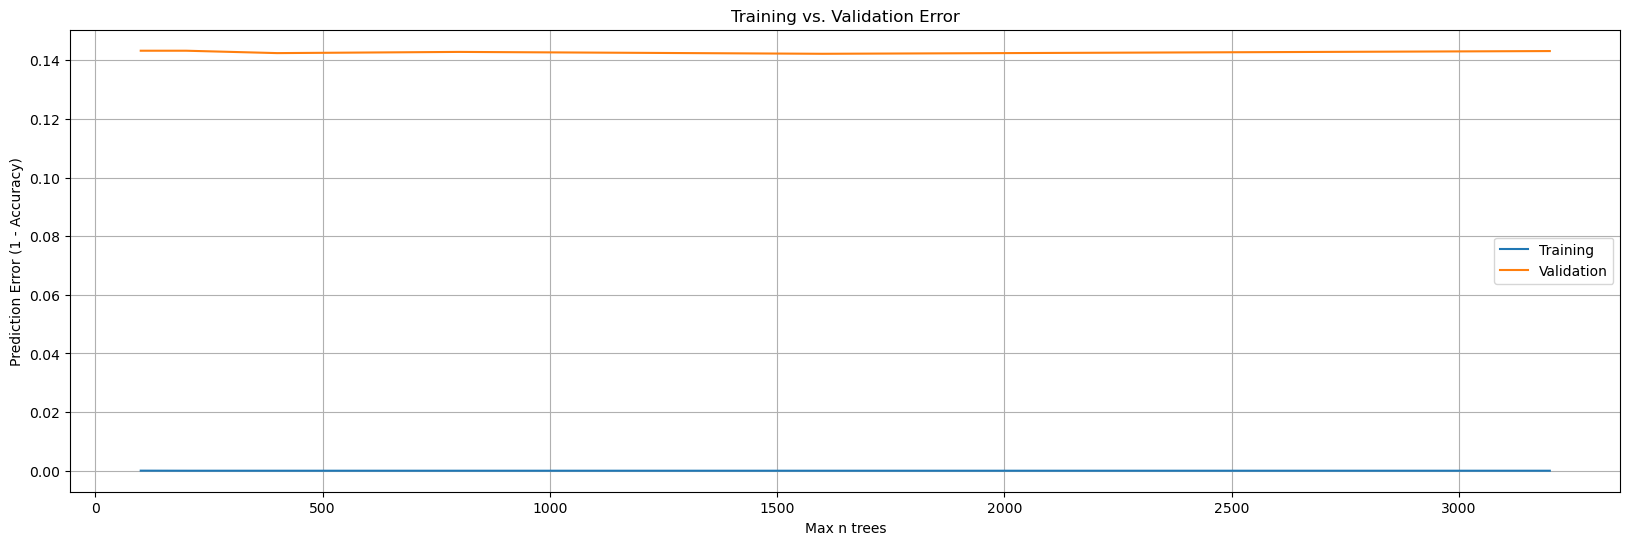

In [53]:
plt.figure(figsize = (20,6))
plt.plot(errors_df['max n trees'], errors_df['Training Error'])
plt.plot(errors_df['max n trees'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks()
plt.xlabel('Max n trees')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.show()

2- max_depth & max_leaf_nodes

In [55]:
def max_depth_error(md):
    
    model = RandomForestClassifier(max_depth = md, random_state = 42, n_jobs = -1)
    model.fit(x_train, train_targets)
    train_acc = 1 - model.score(x_train, train_targets)
    val_acc = 1 - model.score(x_val, val_targets)
    return{'Max depth' : md, 'Training Error' : train_acc, 'Validation Error' : val_acc}
    
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 40)])
errors_df

,Max depth,Training Error,Validation Error
0,1,0.225108,0.211711
1,2,0.224492,0.211537
2,3,0.206187,0.198944
3,4,0.191730,0.186582
4,5,0.178163,0.173815
5,6,0.170455,0.168359
6,7,0.164889,0.165400
7,8,0.158676,0.160002
8,9,0.152988,0.158842
9,10,0.146109,0.155824


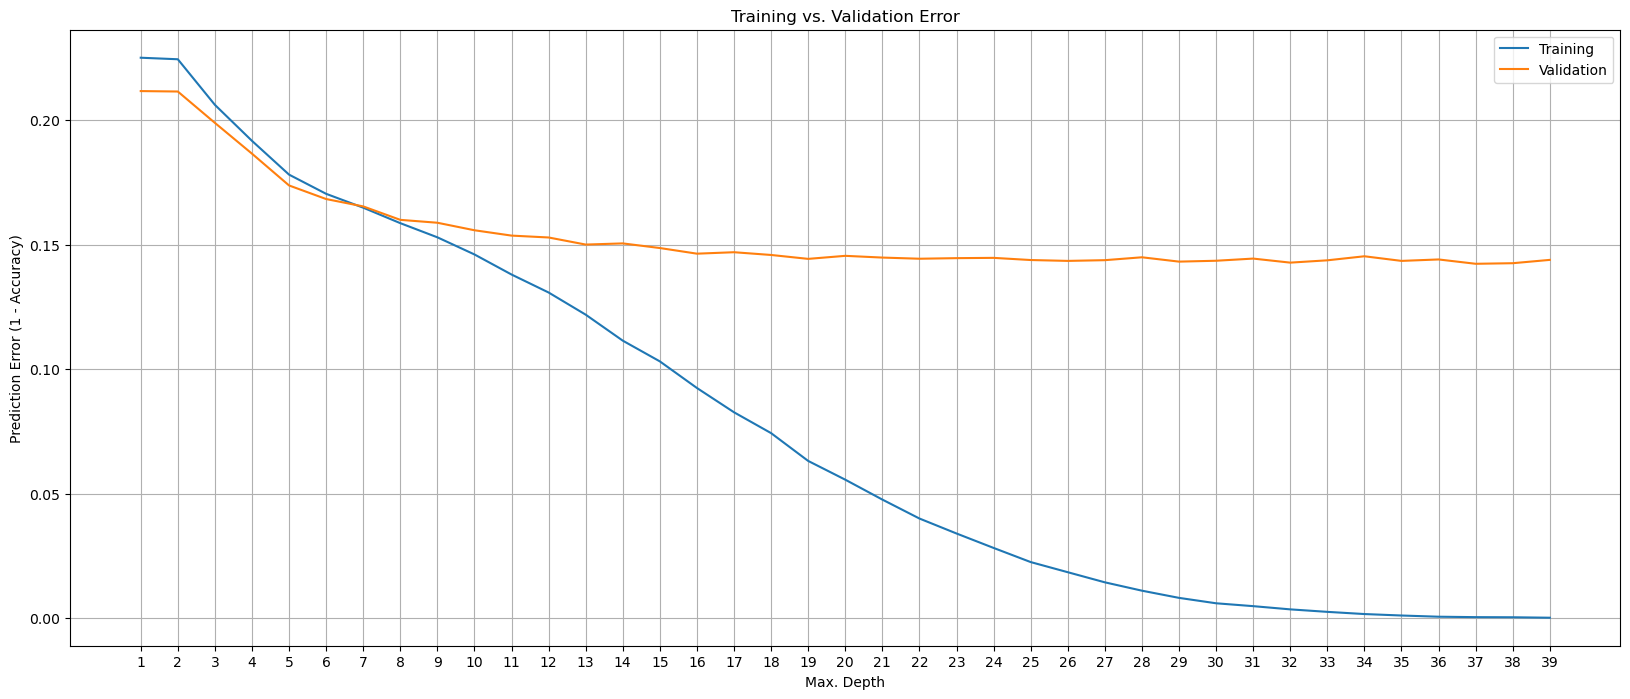

In [56]:
#  سيناريو الافراط في التعلم

plt.figure(figsize = (20, 8))
plt.plot(errors_df['Max depth'], errors_df['Training Error'])
plt.plot(errors_df['Max depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(1, 40, 1))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.show()

In [57]:
# Paython Function Kwargs
def test_params(**params):
    model = RandomForestClassifier(**params, random_state = 42, n_jobs = -1).fit(x_train, train_targets)
    return model.score(x_train, train_targets),model.score(x_val, val_targets)

In [58]:
test_params(max_depth = 5)

(0.8218369903422638, 0.8261853635888805)

In [59]:
test_params(max_depth = 26)

(0.9814927061866084, 0.8564796007196332)

In [60]:
test_params(max_depth = 12)

(0.869176061744858, 0.8470779409204341)

In [61]:
test_params(max_leaf_nodes = 2**5)

(0.8300096981452297, 0.832046892229122)

In [62]:
test_params(max_leaf_nodes = 2**20)

(0.9999696932961571, 0.8547385526086704)

In [63]:
test_params(max_leaf_nodes = 2**12)

(0.9296379359114236, 0.8549706923567988)

3- Max Features
- عدد الميزات (الصفات) التي تؤخذ بعين الاعتبار عند البحث عن أفضل انقسام، والقيمة
 'sqrt' تعني أخذ الجذر التربيعي لعدد الميزات.
- {auto, sqrt, log2}, int, float, deafult = auto
- اذا كان عدد الميزات قليل هذا ليس جيد انه فقط يتعلم واذا كانت كبيره سوف تضيع في الفضاء
- يتم اختيارها من خلال الممارسه

In [65]:
test_params(max_features = 'log2')

(0.9999393865923142, 0.8555510417271197)

In [66]:
test_params(max_features = 'log2', max_depth = 12)

(0.8559017254616721, 0.8423190760838024)

In [67]:
test_params(max_features = 3)

(0.9999494888269285, 0.8516046660089374)

In [68]:
test_params(max_features =  6)

(0.9999393865923142, 0.8555510417271197)

In [69]:
test_params(max_features =  20) #best

(0.9999595910615429, 0.8557831814752481)

4- min_samples_split & min_samples_leaf
- تقسم العقده حسب عدد الاسطر التي فيها او في الورقه
- min_samples_leaf: الحد الأدنى لعدد العينات في ورقة الشجرة
- min_samples_split: الحد الأدنى لعدد العينات اللازمة لتقسيم عقدة (2 بشكل افتراضي) وعند زيادته تقل قوه المودل
- اذا كانت القيم كبيره نكون في القسم الاول واذا كانت قليله نكون في قسم الافراط في التعلم

In [71]:
test_params(min_samples_split = 5, min_samples_leaf = 2)

(0.9575100012122681, 0.8576983343973071)

In [72]:
test_params(min_samples_split = 100, min_samples_leaf = 60)

(0.8494868064815937, 0.8453949277465034)

5- min_impurity_decrease
- عند تقسيم العقده الى عقدتين يكون لهم قيم جيني اذا كانت اكبر من هذه القيمه تكون مفيده غير ذالك يكون التقسيم غير مفيد فقط يزيد من تعقيد النموذج ولا داعي لها
-  القيم بيين 0 و 0.1 تكون افضل القيم

In [74]:
test_params(min_impurity_decrease = 1e-8)

(0.9999393865923142, 0.8561313910974406)

In [75]:
test_params(min_impurity_decrease = 1e-7)

(0.9996060128500425, 0.8559572862863444)

In [76]:
test_params(min_impurity_decrease = 1e-6) #best

(0.988968359801188, 0.8568858452788579)

In [77]:
test_params(min_impurity_decrease = 1e-5)

(0.9206368448700852, 0.8545064128605421)

In [78]:
test_params(min_impurity_decrease = 1e-4)

(0.8369196266214086, 0.8366316522546573)

In [79]:
test_params(min_impurity_decrease = 1e-2)

(0.774891906089627, 0.7882885497069235)

In [80]:
base_acc

(0.9999595910615429, 0.8567697754047937)

6- bootstrap, max_samples:

-  bootstrap : True ->  (True أو False) هل يتم أخذ عينات مع الاستبدال لتكوين كل شجرة؟
-  نقوم بتدريب المودل على جزء من البيانات يمكن ان يتكرر الصف اكثر من مره ويحدد له وزن اعلى او يمكن انا لا ياخذ الصف باكمله
-  يحدق لجميع الاشجار (تكرار هذه الحاله)
-  max_samples: number ->  كم صف يمكن استخدامه في تدريب الشجره من البيانات يساعد في تقليل الافراط في التعلم
-  اذا كانت النسبه اصغر تزيد العشوائيه
-  اذا كانت واحد يمكن ان يزيد التعقيد ويحدث الافراط في التعلم

In [82]:
test_params(bootstrap = True)

(0.9999595910615429, 0.8567697754047937)

In [83]:
test_params(bootstrap = False)

(0.9999797955307714, 0.8565376356566653)

In [84]:
test_params(max_samples = 0.9) #best

(0.9997676486038711, 0.8567697754047937)

In [85]:
test_params(max_samples = 0.8)

(0.9990099810077989, 0.8554930067900877)

In [86]:
test_params(max_samples = 0.1)

(0.8749444377096214, 0.8518948406940978)

7- class_weight

In [88]:
train_targets.value_counts() / len(train_targets)

RainTomorrow
No     0.774892
Yes    0.225108
Name: count, dtype: float64

In [89]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [90]:
test_params(class_weight = 'balanced')

(0.9999494888269285, 0.8548546224827346)

In [91]:
test_params(class_weight = 'balanced_subsample')

(0.9999595910615429, 0.8545644477975741)

In [92]:
test_params(class_weight = {'No' : 1, 'Yes' : 2}) #best

(0.9999595910615429, 0.8552608670419592)

In [93]:
test_params(class_weight = {'No' : 1, 'Yes' :2.5})

(0.9999595910615429, 0.855725146538216)

8- Putting it together

In [95]:
 model = RandomForestClassifier(random_state = 42,
                                n_jobs = -1,
                               class_weight = {'No' : 1, 'Yes' : 1.5},
                               max_features = 20,
                               max_depth = 30,
                               n_estimators = 500,
                               min_samples_split = 5,
                               min_samples_leaf = 2).fit(x_train, train_targets)

In [96]:
model.score(x_train, train_targets),model.score(x_val, val_targets)

(0.9796136905483493, 0.8577563693343393)

In [97]:
base_acc

(0.9999595910615429, 0.8567697754047937)

In [98]:
model.score(x_train, train_targets),model.score(x_val, val_targets)

(0.9796136905483493, 0.8577563693343393)

In [99]:
model.score(x_test, test_targets)

0.8457688457688458

9- دقه النموذج
- قد تعتمد على المتحولات الفائقه
- يمكن نحتاج ان نغير المودل
- البيانات غير كافيه
- يجب زياده عدد الاعمده او الميزات
- نحتاج لانشاء الميزات بواسطه الميزات الموجوده
- قد يكون الهدف ظاهر عشوائيه او فوضويه بطبيعتها مهما كان المود او البيانات او اي شيء

10- Making Predictions on New Inputs

In [102]:
def predict_input(single_input):
    input_df = pd.DataFrame([new_input])
    input_df [numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df [numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
    x_input = input_df[numeric_cols + encoded_cols]
    prediction = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(prediction)]
    return prediction,prob   

In [103]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    

    encoded_df = pd.DataFrame(encoder.transform(input_df[categorical_cols]), columns=encoded_cols, index=input_df.index)
    input_df = pd.concat([input_df.drop(columns=categorical_cols), encoded_df], axis=1)

    x_input = input_df[numeric_cols + encoded_cols]
    prediction = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(prediction)]
    return prediction, prob


In [104]:
new_input = { 'Date' : '2021-06-19',
             'Location' : 'Katherin',
             'MinTemp' : 23.2,
             'MaxTemp' : 33.2,
             'Rainfall' : 10.2,
             'Evaporation' : 4.2,
             'Sunshine' : np.nan,
             'WindGustDir' : 'NNW',
             'WindGustSpeed' : 52.0,
             'WindDir9am' : 'NW',
             'WindDir3pm' : 'NNE',
             'WindSpeed9am' : 13.0,
             'WindSpeed3pm' : 20.0,
             'Humidity9am' : 89.0,
             'Humidity3pm' : 58.0,
             'Pressure9am' : 1004.8,
             'Pressure3pm' : 1001.5,
             'Cloud9am' : 8.0, 
             'Cloud3pm' : 5.0,
             'Temp9am' : 25.7,
             'Temp3pm' : 33.0,
             'RainToday' : 'Yes'
            }        

In [105]:
predict_input(new_input)

('Yes', 0.7784975252158394)

In [181]:
import joblib

In [204]:
aussie_rain_randomForest = {
    'model' : model,
    'imputer' : imputer,
    'scaler' : scaler,
    'encoder' : encoder,
    'inputs_cols' : inputs_cols,
    'targets_cols' : targets_cols,
    'numeric_cols' : numeric_cols,
    'categorical_cols' : categorical_cols,
    'encoded_cols' : encoded_cols,
    'predict_input' : predict_input,
    'predict' : predict,
    'test_params' : test_params
}

In [206]:
joblib.dump(aussie_rain_randomForest, 'aussie_rain_randomForest.joblib')

['aussie_rain_randomForest.joblib']

In [214]:
z = joblib.load('aussie_rain_randomForest.joblib')

In [222]:
z.keys()

dict_keys(['model', 'imputer', 'scaler', 'encoder', 'inputs_cols', 'targets_cols', 'numeric_cols', 'categorical_cols', 'encoded_cols', 'predict_input', 'predict', 'test_params'])

In [233]:
importance_df = pd.DataFrame({
    'features' : x_train.columns,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending = False)

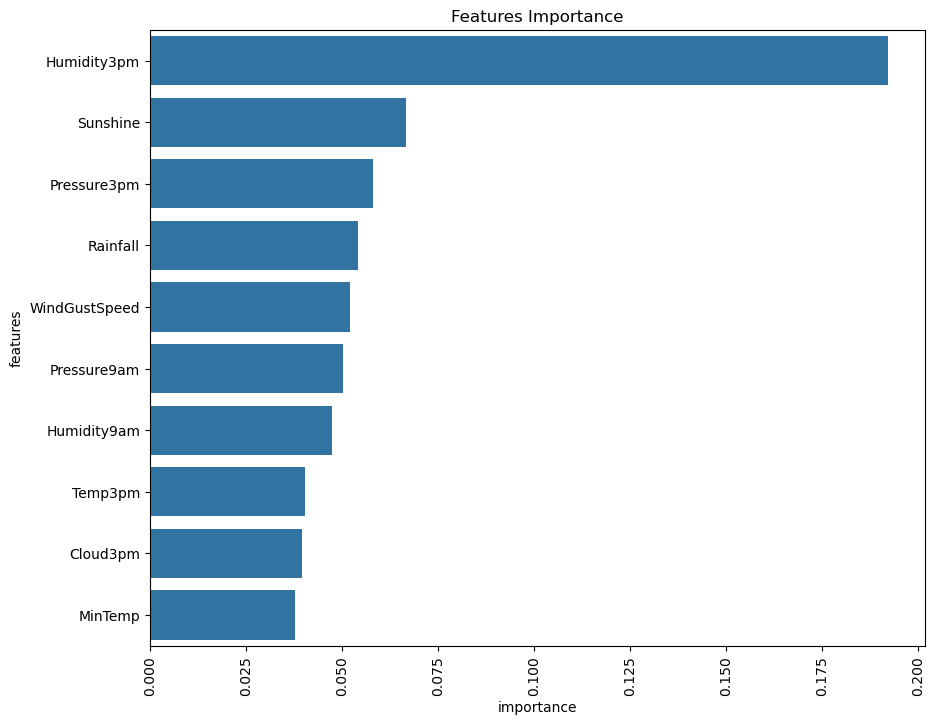

In [235]:
plt.figure(figsize = (10, 8))
plt.title('Features Importance')
sns.barplot(data = importance_df.head(10), y = 'features', x = 'importance')
plt.xticks(rotation = 90)
plt.show()

In [228]:
o = pd.DataFrame([z])

### 1. Hyperparameter Tuning (ضبط المعاملات الفائقة):

- المعاملات الفائقة هي إعدادات خارجية لنموذج التعلم الآلي لا يتم تعلمها من البيانات، بل يحددها الإنسان قبل التدريب، مثل:
  - عدد الأشجار في الغابة العشوائية (Random Forest)
  - معدل التعلم (learning rate) في الشبكات العصبية
  - عمق الشجرة (tree depth)

- تعديل هذه المعاملات بطريقة صحيحة يُحسن من أداء النموذج ودقته.

- تستخدم طرق مثل:
  - البحث الشبكي (Grid Search)
  - البحث العشوائي (Random Search)
  - خوارزميات تحسين متقدمة (مثل Bayesian Optimization)

للبحث عن أفضل مجموعة من المعاملات التي تعطي أفضل نتائج.

---

### 2. Regularization (التنظيم أو التقييد):

- تقنية تُستخدم للحد من مشكلة الإفراط في التعلّم (overfitting)، عندما يتعلم النموذج كثيرًا تفاصيل بيانات التدريب حتى لا يعمم جيدًا على بيانات جديدة.

- الفكرة: تقييد حجم أو تعقيد النموذج عبر إضافة عقوبة (penalty) على القيم الكبيرة للمعاملات (weights) في النموذج.

- أنواع شائعة:
  - L1 Regularization (Lasso): تقلل بعض الأوزان إلى صفر، مما يؤدي إلى اختيار ميزات مهمة فقط.
  - L2 Regularization (Ridge): تقلل قيم الأوزان الكبيرة بشكل عام لكنها لا تلغيها.

- يساعد التنظيم النموذج على التعميم بشكل أفضل وتحسين أداءه على بيانات لم يرها من قبل.

---

### 1. Ensembling (التجميع أو التشكيل)

- هي تقنية تستخدم لدمج عدة نماذج تعلم آلي معًا للحصول على نموذج واحد أقوى.
- الفكرة: يجمع النموذج النهائي نتائج نماذج متعددة لتقليل الأخطاء وزيادة الدقة.
- طرق شائعة:
  - Bagging (مثل Random Forest): تدريب نماذج متعددة على مجموعات بيانات مختلفة ثم دمج نتائجها.
  - Boosting (مثل AdaBoost, Gradient Boosting): بناء نماذج متتالية حيث كل نموذج يحاول تصحيح أخطاء النموذج السابق.
  - Stacking: دمج مخرجات نماذج مختلفة باستخدام نموذج آخر.

---

### 2. Generalization (التعميم)

- تعني قدرة النموذج على تقديم أداء جيد وموثوق عليه على بيانات جديدة لم يرها أثناء التدريب.
- نموذج جيد لا يقتصر على حفظ بيانات التدريب فقط وإنما يفهم الأنماط التي تمكنه من التنبؤ الصحيح في مواقف جديدة.
- مشاكل شائعة:
  - Overfitting: عندما يتعلم النموذج التفاصيل الدقيقة للبيانات التدريبية بشكل مفرط ولا يعمم جيدًا.
  - Underfitting: عندما يكون النموذج بسيطًا جدا ولا يستطيع تعلم الأنماط المهمة في البيانات.

---

### 3. Bootstraping (التكرار مع الاستبدال)

- هي تقنية أخذ عينات من البيانات بحجم يساوي حجم بيانات التدريب ولكن بسحب العينات مع إمكانية إعادة نفس العنصر أكثر من مرة.
- تُستخدم لإنشاء مجموعات بيانات مختلفة من نفس مجموعة البيانات الأصلية.
- تُستخدم في تقنيات مثل Bagging لتحسين الاستقرار وتقليل التذبذب في النموذج.
- تساعد في تقدير دقة النموذج عبر تجارب متعددة على عينات مختلفة.

In [106]:
%%time

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_features' : [i for i in range(1,20)],
    #'max_depth': [i for i in range(1,40)],
    #'criterion': ['gini', 'entropy'],
    #'max_leaf_nodes' :[[i for i in range(0,2**30)],
    #'min_samples_split' : [i for i in range(3, 10)],
    #'min_samples_leaf' :  [i for i in range(3, 10)],
    #'bootstrap' : [True, False]
}

clf = RandomForestClassifier(random_state = 42, n_jobs = -1)
grid_search = GridSearchCV(estimator = clf, param_grid = param_grid, cv = 10)
grid_search.fit(x_train, train_targets)

print("best params: ", grid_search.best_params_)
print("best score: ", grid_search.best_score_)


KeyboardInterrupt: 